In [30]:
import numpy as np
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA

# Corpus Creation

For this project we made a tiny toy vocabulary consisting of animates, foods, and toys, as well as verbs and adjectives relating to those groups. The generate corpus function produces four types of sentences:

animate-verb-food ("the cat ate the fish")

animate-verb-toy ("the baby held the ball")

animate-verb-animate ("the cat saw the baby")

predicate-adjective ("the fish was delicious")

From these sentences, we also can create two-sentence anaphoras like ("the cat ate the fish. It was delicious.")

The one-hot function then converts each word index into a vector the network can take as an input.

In [31]:
# ------------------------------------------------------------------ #
#  Vocabulary
# ------------------------------------------------------------------ #

ANIMATES = ["cat", "dog", "baby", "bird", "mouse"]
FOODS    = ["fish", "meat", "bread", "soup", "milk"]
TOYS     = ["ball", "bell", "block", "doll", "drum"]

EAT_VERBS  = [("eats", "ate"),    ("wants", "wanted"),  ("likes", "liked")]
HOLD_VERBS = [("holds", "held"),  ("drops", "dropped"), ("rolls", "rolled")]
SEE_VERBS  = [("sees", "saw"),    ("watches", "watched")]

FOOD_ADJS = ["delicious", "tasty"]
TOY_ADJS  = ["round",     "soft",  "noisy"]


def generate_corpus():
    s = []
    for animate in ANIMATES:
        for verb_present, verb_past in EAT_VERBS:
            for food in FOODS:
                s.append(f"the {animate} {verb_present} the {food} .")
                s.append(f"the {animate} {verb_past} the {food} .")
        for verb_present, verb_past in HOLD_VERBS:
            for toy in TOYS:
                s.append(f"the {animate} {verb_present} the {toy} .")
                s.append(f"the {animate} {verb_past} the {toy} .")
    for a1 in ANIMATES:
        for verb_present, verb_past in SEE_VERBS:
            for a2 in ANIMATES:
                if a1 != a2:
                    s.append(f"the {a1} {verb_present} the {a2} .")
                    s.append(f"the {a1} {verb_past} the {a2} .")
    for food in FOODS:
        for adj in FOOD_ADJS:
            s.append(f"the {food} is {adj} .")
            s.append(f"the {food} was {adj} .")
    for toy in TOYS:
        for adj in TOY_ADJS:
            s.append(f"the {toy} is {adj} .")
            s.append(f"the {toy} was {adj} .")
    for animate in ANIMATES:
        for food in FOODS:
            for verb_present, verb_past in EAT_VERBS:
                adj = random.choice(FOOD_ADJS)
                s.append(f"the {animate} {verb_past} the {food} . it was {adj} .")
                s.append(f"the {animate} {verb_present} the {food} . it is {adj} .")
        for toy in TOYS:
            for verb_present, verb_past in HOLD_VERBS:
                adj = random.choice(TOY_ADJS)
                s.append(f"the {animate} {verb_past} the {toy} . it was {adj} .")
                s.append(f"the {animate} {verb_present} the {toy} . it is {adj} .")
    return s


sentences = generate_corpus()
print(f"Generated {len(sentences)} sentences")

vocab    = sorted(set(" ".join(sentences).split()))
word2idx = {w: i for i, w in enumerate(vocab)}
V        = len(vocab)
print(f"Vocabulary size: {V}")


def one_hot(i, n):
    v = np.zeros(n)
    v[i] = 1.0
    return v


Generated 730 sentences
Vocabulary size: 41


In [43]:
generate_corpus()

['the cat eats the fish .',
 'the cat ate the fish .',
 'the cat eats the meat .',
 'the cat ate the meat .',
 'the cat eats the bread .',
 'the cat ate the bread .',
 'the cat eats the soup .',
 'the cat ate the soup .',
 'the cat eats the milk .',
 'the cat ate the milk .',
 'the cat wants the fish .',
 'the cat wanted the fish .',
 'the cat wants the meat .',
 'the cat wanted the meat .',
 'the cat wants the bread .',
 'the cat wanted the bread .',
 'the cat wants the soup .',
 'the cat wanted the soup .',
 'the cat wants the milk .',
 'the cat wanted the milk .',
 'the cat likes the fish .',
 'the cat liked the fish .',
 'the cat likes the meat .',
 'the cat liked the meat .',
 'the cat likes the bread .',
 'the cat liked the bread .',
 'the cat likes the soup .',
 'the cat liked the soup .',
 'the cat likes the milk .',
 'the cat liked the milk .',
 'the cat holds the ball .',
 'the cat held the ball .',
 'the cat holds the bell .',
 'the cat held the bell .',
 'the cat holds the 

# Sensorimotor features

For each grounded word in our toy vocabulary, we have 6 sensorimotor dimensions to measure their features: Roughness, loudness, odor, mobility, edibility, and size, to correspond with the use of our senses. For each feature, a word is given a score on a scale of 0 to 1, where for a feature like "odor" 1 would indicate something extremely pungent while 0 would indicate that the object has no smell.

In [32]:
F = 6
FEAT_NAMES = ["rough", "loud", "odor", "moves", "edible", "large"]

features = {
    "cat":   np.array([0.3, 0.3, 0.3, 1.0, 0.0, 0.4]),
    "dog":   np.array([0.4, 0.6, 0.4, 1.0, 0.0, 0.6]),
    "baby":  np.array([0.2, 0.7, 0.3, 0.8, 0.0, 0.3]),
    "bird":  np.array([0.2, 0.4, 0.2, 1.0, 0.0, 0.2]),
    "mouse": np.array([0.3, 0.2, 0.2, 1.0, 0.0, 0.1]),
    "fish":  np.array([0.3, 0.0, 1.0, 0.0, 1.0, 0.2]),
    "meat":  np.array([0.4, 0.0, 0.8, 0.0, 1.0, 0.3]),
    "bread": np.array([0.5, 0.0, 0.5, 0.0, 1.0, 0.3]),
    "soup":  np.array([0.0, 0.0, 0.7, 0.0, 1.0, 0.2]),
    "milk":  np.array([0.0, 0.0, 0.4, 0.0, 1.0, 0.2]),
    "ball":  np.array([0.1, 0.1, 0.0, 0.3, 0.0, 0.4]),
    "bell":  np.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.2]),
    "block": np.array([0.4, 0.0, 0.0, 0.0, 0.0, 0.3]),
    "doll":  np.array([0.1, 0.0, 0.0, 0.0, 0.0, 0.4]),
    "drum":  np.array([0.2, 0.9, 0.0, 0.0, 0.0, 0.4]),
    "eats":    np.array([0.0, 0.1, 0.2, 0.2, 0.5, 0.0]),
    "ate":     np.array([0.0, 0.1, 0.2, 0.2, 0.5, 0.0]),
    "wants":   np.array([0.0, 0.0, 0.1, 0.1, 0.3, 0.0]),
    "wanted":  np.array([0.0, 0.0, 0.1, 0.1, 0.3, 0.0]),
    "likes":   np.array([0.0, 0.0, 0.1, 0.1, 0.2, 0.0]),
    "liked":   np.array([0.0, 0.0, 0.1, 0.1, 0.2, 0.0]),
    "holds":   np.array([0.0, 0.0, 0.0, 0.1, 0.0, 0.0]),
    "held":    np.array([0.0, 0.0, 0.0, 0.1, 0.0, 0.0]),
    "drops":   np.array([0.0, 0.1, 0.0, 0.5, 0.0, 0.0]),
    "dropped": np.array([0.0, 0.1, 0.0, 0.5, 0.0, 0.0]),
    "rolls":   np.array([0.0, 0.0, 0.0, 0.8, 0.0, 0.0]),
    "rolled":  np.array([0.0, 0.0, 0.0, 0.8, 0.0, 0.0]),
    "sees":    np.array([0.0, 0.0, 0.0, 0.1, 0.0, 0.0]),
    "saw":     np.array([0.0, 0.0, 0.0, 0.1, 0.0, 0.0]),
    "watches": np.array([0.0, 0.0, 0.0, 0.1, 0.0, 0.0]),
    "watched": np.array([0.0, 0.0, 0.0, 0.1, 0.0, 0.0]),
    "delicious": np.array([0.0, 0.0, 0.6, 0.0, 1.0, 0.0]),
    "tasty":     np.array([0.0, 0.0, 0.5, 0.0, 1.0, 0.0]),
    "round":     np.array([0.0, 0.0, 0.0, 0.2, 0.0, 0.4]),
    "soft":      np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.2]),
    "noisy":     np.array([0.0, 1.0, 0.0, 0.0, 0.0, 0.0]),
}


def encode_sentence(sent):
    toks   = sent.split()
    X      = [one_hot(word2idx[w], V) for w in toks[:-1]]
    Y_word = [word2idx[w] for w in toks[1:]]
    Y_feat = [(features[w], 1.0) if w in features else (np.zeros(F), 0.0)
              for w in toks[:-1]]
    return X, Y_word, Y_feat


episodes = [encode_sentence(s) for s in sentences]

# Weights

In [33]:

H = 64
np.random.seed(0)

# weights from input word  -> hidden layer
W_xh  = np.random.randn(H, V) * 0.1
# weights from previous hidden layer -> current hidden layer
W_hh  = np.random.randn(H, H) * 0.1
# weights from hidden layer -> next-word output
W_word = np.random.randn(V, H) * 0.1
# weights from hidden layer -> feature output
W_feat = np.random.randn(F, H) * 0.1

bias_hidden   = np.zeros(H)   # bias for hidden layer
bias_word     = np.zeros(V)   # bias for next-word output
bias_feat     = np.zeros(F)   # bias for feature output


# Forward Pass

In [34]:


def forward_pass(inputs, h_prev):
    # Hidden layer has 2 inputs: Encoded word input and the previous hidden layer. Each are multplied by their respective input->hidden or hidden->hidden weight matrix, then summed together with the bias.
    # np.tanh restricts activation between -1 and 1
    h = np.tanh(W_xh @ inputs + W_hh @ h_prev + bias_hidden)

    # next-word output
    # Hidden layer activation multiplied by hidden->word output weight matrix, summed with bias
    z = W_word @ h + bias_word

    z -= z.max()

    # convert raw scores to probabilities that sum to 1 (softmax)
    y = np.exp(z) / np.exp(z).sum()
    # feature output squashed to [0, 1]
    f = 1 / (1 + np.exp(-(W_feat @ h + bias_feat)))

    return h, y, f



# Training

In [35]:
MSE_word_list = []
MSE_feat_list = []

def training(episodes, lr=0.02, epochs=500):
    global W_xh, W_hh, W_word, W_feat, bias_hidden, bias_word, bias_feat
    for epoch in range(epochs):
        total_word_loss = 0.0
        total_feat_loss = 0.0

        random.shuffle(episodes)

        #Loops through every sentence, one sentence at a time
        for X, Y_word, Y_feat in episodes:

            #Forward pass, hidden layer initially filled with zeroes, outputs are stored
            h = np.zeros(H)
            all_hidden = [h]
            all_word_outputs = []
            all_feat_outputs = []

            for inputs in X:
                h, y, f = forward_pass(inputs, h)
                all_hidden.append(h)
                all_word_outputs.append(y)
                all_feat_outputs.append(f)

            #Backward pass, go through the sentence in reverse word by word
            #Ex. In "The cat ate the fish. It was delicious.", we start at "delicious" and go backward.

            error_from_future = np.zeros(H)

            for t in reversed(range(len(X))):

                # Zeroes out feature error for ungrounded words
                # Ex. In "The cat ate the fish. It was delicious"
                target, mask = Y_feat[t]

                # Probability distribution of predicted word, then subtract 1 to find the error for the word at an index.
                # Ex. In "The cat ate the fish. It was delicious." the word delicious is given a predicted probability of 0.4, then we get -0.6 error.
                e_word = all_word_outputs[t].copy()
                e_word[Y_word[t]] -= 1

                # Computes error for features
                e_feat = mask * (all_feat_outputs[t] - target) * all_feat_outputs[t] * (1 - all_feat_outputs[t])

                # error flows back from both outputs into the shared hidden state, combining the error from word prediction and feature prediction
                error_hidden = W_word.T @ e_word + W_feat.T @ e_feat + error_from_future

                # pass the error back through the tanh and clips it to prevent explosion
                error_hidden_raw = (1 - all_hidden[t+1] ** 2) * error_hidden
                np.clip(error_hidden_raw, -5, 5, out=error_hidden_raw)

                # update weights from hidden -> next-word output
                # multiplies error by activations in the hidden layer and by learning rate
                W_word    -= lr * np.outer(e_word, all_hidden[t+1])
                bias_word -= lr * e_word

                # update weights from hidden -> feature output
                # multiplies error by activations in the hidden layer and by learning rate
                W_feat    -= lr * np.outer(e_feat, all_hidden[t+1])
                bias_feat -= lr * e_feat

                # update weights from input word -> hidden
                # multiplies error by the encoded one-hot input vector and by learning rate
                W_xh -= lr * np.outer(error_hidden_raw, X[t])

                # update weights from previous hidden -> current hidden
                # multiplies error by activations in the previous hidden layer and by learning rate
                W_hh        -= lr * np.outer(error_hidden_raw, all_hidden[t])
                bias_hidden -= lr * error_hidden_raw

                # carry error back to the previous timestep
                # hidden state at time t-1 gets updated based also on how much it contributed to error at time t. This gets carried to t-2, t-3, and so on.
                error_from_future = W_hh.T @ error_hidden_raw

                total_word_loss += -np.log(all_word_outputs[t][Y_word[t]] + 1e-12)
                total_feat_loss += mask * 0.5 * np.sum((all_feat_outputs[t] - target) ** 2)

        MSE_word_list.append(total_word_loss)
        MSE_feat_list.append(total_feat_loss)

        if epoch % 50 == 0:
            print(f"epoch {epoch:4d}   word-loss {total_word_loss:.2f}   feat-MSE {total_feat_loss:.5f}")

#Trains network for 200 epochs
training(episodes, lr=0.02, epochs=200)


epoch    0   word-loss 7359.24   feat-MSE 445.77328
epoch   50   word-loss 4787.40   feat-MSE 4.52405
epoch  100   word-loss 4799.90   feat-MSE 6.32829
epoch  150   word-loss 4769.69   feat-MSE 5.41725


# Helper Functions

In [36]:
def features_for(prefix, current):
    h = np.zeros(H)
    for w in prefix:
        h, _, _ = forward_pass(one_hot(word2idx[w], V), h)
    h, _, f = forward_pass(one_hot(word2idx[current], V), h)
    return f

def cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-12 or nb < 1e-12: return 0.0
    return float(a @ b / (na * nb))

def euclidean(a, b):
    return float(np.linalg.norm(a - b))

def nearest_by_cosine(vec, k=5):
    return sorted([(w, cosine(vec, t)) for w, t in features.items()], key=lambda x: -x[1])[:k]

def nearest_by_euclidean(vec, k=5):
    return sorted([(w, euclidean(vec, t)) for w, t in features.items()], key=lambda x: x[1])[:k]


CATEGORY = {}
for w in ANIMATES:                              CATEGORY[w] = "animate"
for w in FOODS:                                 CATEGORY[w] = "food"
for w in TOYS:                                  CATEGORY[w] = "toy"
for vp, vt in EAT_VERBS + HOLD_VERBS + SEE_VERBS:
    CATEGORY[vp] = CATEGORY[vt] = "verb"
for w in FOOD_ADJS + TOY_ADJS:                 CATEGORY[w] = "adj"

COLORS = {"animate": "#d62728", "food": "#2ca02c", "toy": "#1f77b4",
          "verb": "#7f7f7f",    "adj":  "#9467bd"}


# Plot 1: Loss Curves
Training loss over epochs for both tasks. Word loss is cross-entropy on next-word prediction. Lower cross-entropy means the network is better at predicting what word comes next. Feature MSE is the mean squared error on sensorimotor feature prediction. Lower MSE means the network's internal representations are closer to the grounded feature targets.

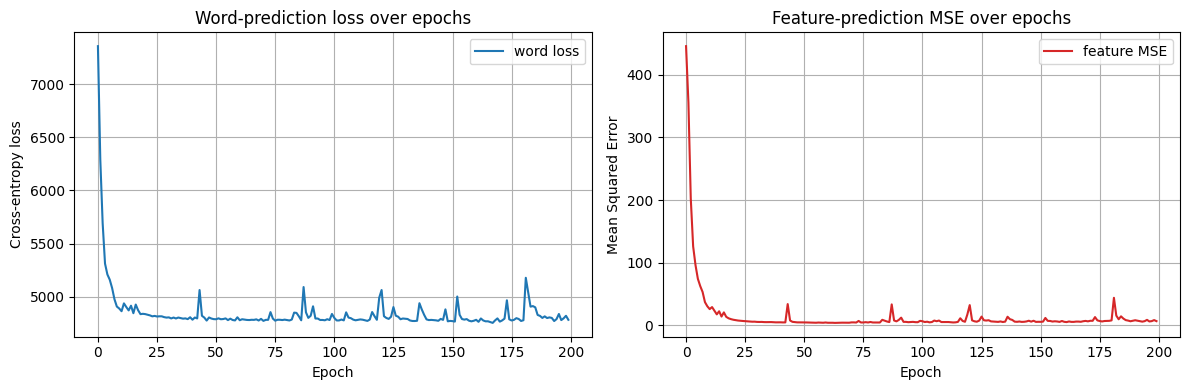

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(MSE_word_list, label="word loss")
axs[0].set_xlabel("Epoch"); axs[0].set_ylabel("Cross-entropy loss")
axs[0].set_title("Word-prediction loss over epochs")
axs[0].grid(True); axs[0].legend()

axs[1].plot(MSE_feat_list, label="feature MSE", color="#d62728")
axs[1].set_xlabel("Epoch"); axs[1].set_ylabel("Mean Squared Error")
axs[1].set_title("Feature-prediction MSE over epochs")
axs[1].grid(True); axs[1].legend()

plt.tight_layout(); plt.show()


# Plot 2: Predicted vs Target Feature activations for grounded words

For these plots, we look to see the predicted feature values for certain grounded words and compare it against the target feature values that we hand-coded for each word earlier. As a result, we can see how successfully the network associates sensorimotor features with grounded words.

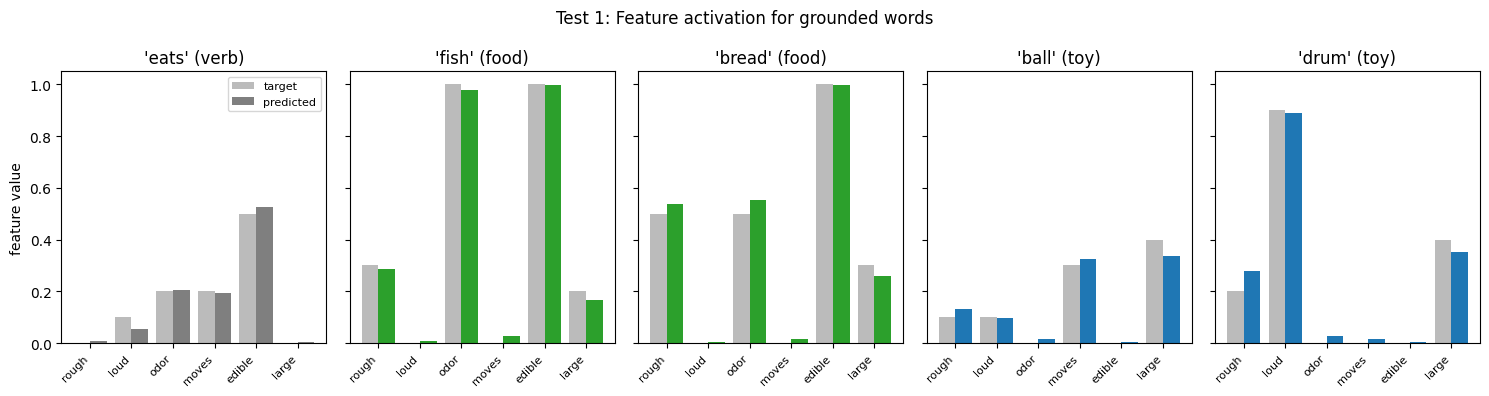

In [38]:
probes = [
    (["the", "cat"],                  "eats",  "verb"),
    (["the", "cat", "eats", "the"],   "fish",  "food"),
    (["the", "dog", "eats", "the"],   "bread", "food"),
    (["the", "baby", "holds", "the"], "ball",  "toy"),
    (["the", "cat", "holds", "the"],  "drum",  "toy"),
]
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=True)
x = np.arange(F)
for ax, (prefix, w, cat) in zip(axes, probes):
    ax.bar(x - 0.2, features[w],             0.4, color="#bbbbbb",   label="target")
    ax.bar(x + 0.2, features_for(prefix, w), 0.4, color=COLORS[cat], label="predicted")
    ax.set_xticks(x); ax.set_xticklabels(FEAT_NAMES, rotation=45, ha="right", fontsize=8)
    ax.set_title(f"'{w}' ({cat})"); ax.set_ylim(0, 1.05)
axes[0].set_ylabel("feature value"); axes[0].legend(fontsize=8)
fig.suptitle("Test 1: Feature activation for grounded words")
plt.tight_layout(); plt.show()


# Plot 3: Propogation of Grounding from grounded to abstract words


Tests whether grounded features propagate to ungrounded words through context. "it" has no sensorimotor features associated with it, but after a sentence like "the cat ate the fish", the network should have a hidden state representation that resembles food with food-like features.

The plots measure the cosine similarity and euclidean distance between the hidden state vector for "it" and for the hidden state vector of every grounded word in the vocabulary. A higher cosine similarity indicates that these vectors are pointing in the same direction, while a low Euclidan distance indicates that these vectors are similar in magnitude.

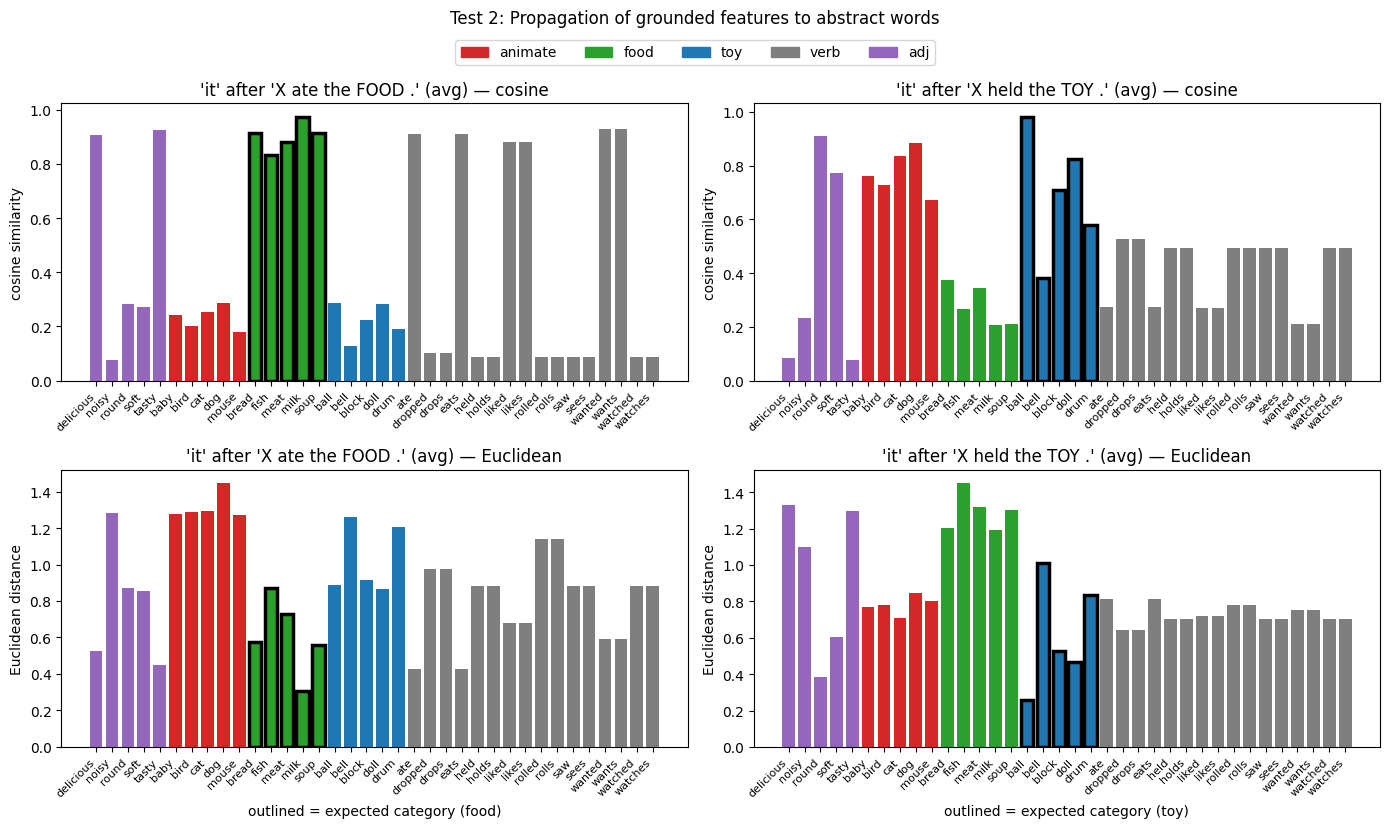

In [39]:
food_probes = [features_for(["the", a, "ate",  "the", f, "."], "it") for a in ANIMATES for f in FOODS]
toy_probes  = [features_for(["the", a, "held", "the", t, "."], "it") for a in ANIMATES for t in TOYS]
it_food     = np.mean(food_probes, axis=0)
it_toy      = np.mean(toy_probes,  axis=0)
ordered     = sorted(features.keys(), key=lambda w: (CATEGORY[w], w))

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for col, (vec, label, expected) in enumerate([
    (it_food, "'it' after 'X ate the FOOD .' (avg)",  "food"),
    (it_toy,  "'it' after 'X held the TOY .' (avg)",  "toy"),
]):
    sims  = [cosine(vec, features[w])    for w in ordered]
    dists = [euclidean(vec, features[w]) for w in ordered]
    cs    = [COLORS[CATEGORY[w]]         for w in ordered]

    for row, (vals, ylabel, title) in enumerate([
        (sims,  "cosine similarity", f"{label} — cosine"),
        (dists, "Euclidean distance", f"{label} — Euclidean"),
    ]):
        ax   = axes[row, col]
        bars = ax.bar(range(len(ordered)), vals, color=cs)
        for i, w in enumerate(ordered):
            if CATEGORY[w] == expected:
                bars[i].set_edgecolor("black"); bars[i].set_linewidth(2.5)
        ax.set_title(title); ax.set_ylabel(ylabel)
        ax.set_xticks(range(len(ordered)))
        ax.set_xticklabels(ordered, rotation=45, ha="right", fontsize=8)
        ax.tick_params(labelbottom=True)
        if row == 0: ax.axhline(0, color="black", linewidth=0.5)
        if row == 1: ax.set_xlabel(f"outlined = expected category ({expected})")

handles = [mpatches.Patch(color=c, label=cat) for cat, c in COLORS.items()]
fig.legend(handles=handles, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.0))
fig.suptitle("Test 2: Propagation of grounded features to abstract words", y=1.03)
plt.tight_layout(); plt.show()


# Plot 3: Feature Activations of the word 'it' in different contexts

Here we directly compare the activations for each sensorimotor feature of 'it' in two different contexts. In the first, we have a food context "The cat ate the fish" preceding 'it' while in the second we have the toy context "The baby held the ball" preceding 'it'.

We see that in these different contexts, the word 'it' has different feature activations that reflect the words the preceded it.

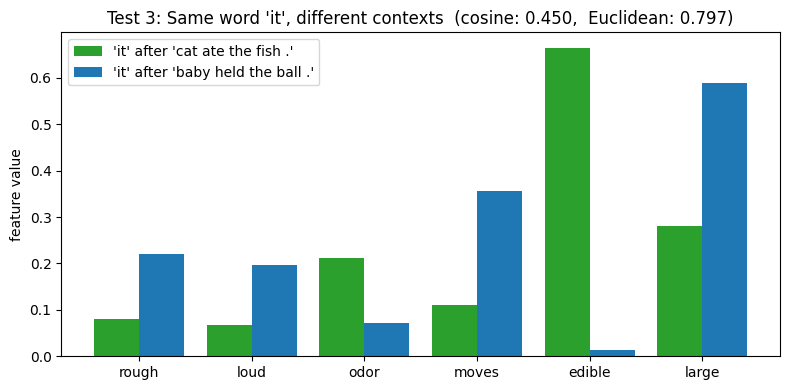

In [40]:
it_food = features_for(["the", "cat",  "ate",  "the", "fish", "."], "it")
it_toy  = features_for(["the", "baby", "held", "the", "ball", "."], "it")

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(F)
ax.bar(x - 0.2, it_food, 0.4, color="#2ca02c", label="'it' after 'cat ate the fish .'")
ax.bar(x + 0.2, it_toy,  0.4, color="#1f77b4", label="'it' after 'baby held the ball .'")
ax.set_xticks(x); ax.set_xticklabels(FEAT_NAMES)
ax.set_ylabel("feature value"); ax.legend()
ax.set_title(f"Test 3: Same word 'it', different contexts  "
             f"(cosine: {cosine(it_food, it_toy):.3f},  Euclidean: {euclidean(it_food, it_toy):.3f})")
plt.tight_layout(); plt.show()


# Plot 4: PCA of Hidden Unit Space

Projects the 64-dimensional hidden state down to 2D using PCA, with one point per grounded word recorded after it was processed. This plot shows how the network organized its interal representational space after training, with words with similar sensorimotor features clustering together.

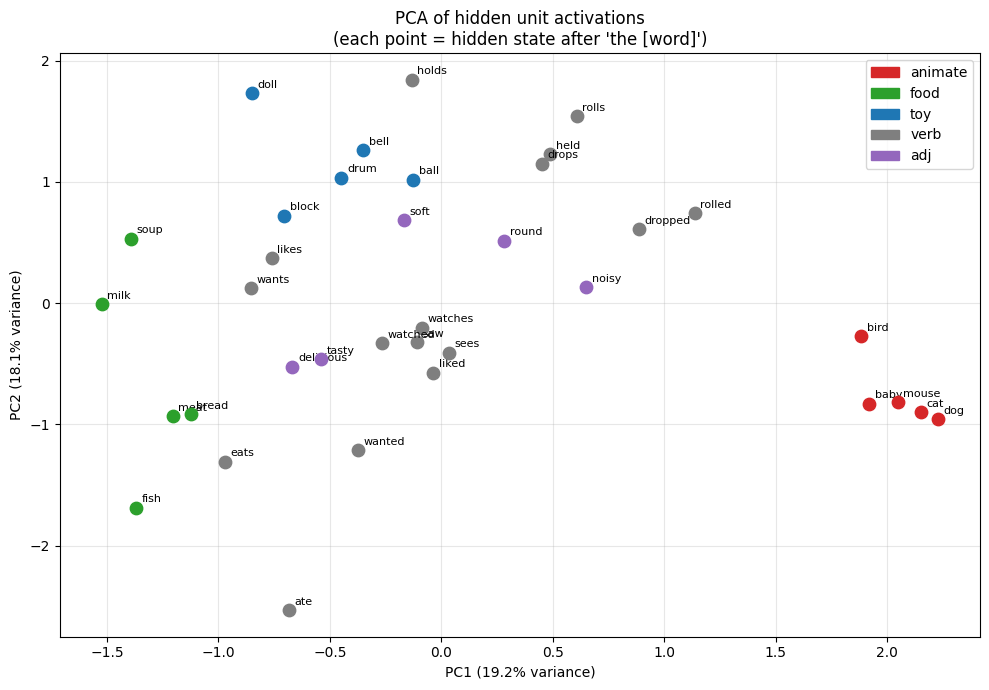

In [41]:
grounded_words = list(features.keys())
hidden_states  = []
for w in grounded_words:
    h = np.zeros(H)
    h, _, _ = forward_pass(one_hot(word2idx["the"], V), h)
    h, _, _ = forward_pass(one_hot(word2idx[w],    V), h)
    hidden_states.append(h)

pca    = PCA(n_components=2)
coords = pca.fit_transform(np.array(hidden_states))
var    = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 7))
for i, w in enumerate(grounded_words):
    ax.scatter(coords[i, 0], coords[i, 1], color=COLORS[CATEGORY[w]], s=80, zorder=3)
    ax.annotate(w, (coords[i, 0], coords[i, 1]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
handles = [mpatches.Patch(color=c, label=cat) for cat, c in COLORS.items()]
ax.legend(handles=handles, loc="upper right")
ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% variance)")
ax.set_title("PCA of hidden unit activations\n(each point = hidden state after 'the [word]')")
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


In this plot, we show the path the hidden state takes through the same PCA space as it processes a full sentence word by word. Each arrow is one timestep.

Here, we can see how the network moves through semantic space, entering "food" or "toy" regions as it processes the sentence, and we can see where 'it' lands relative to those regions.


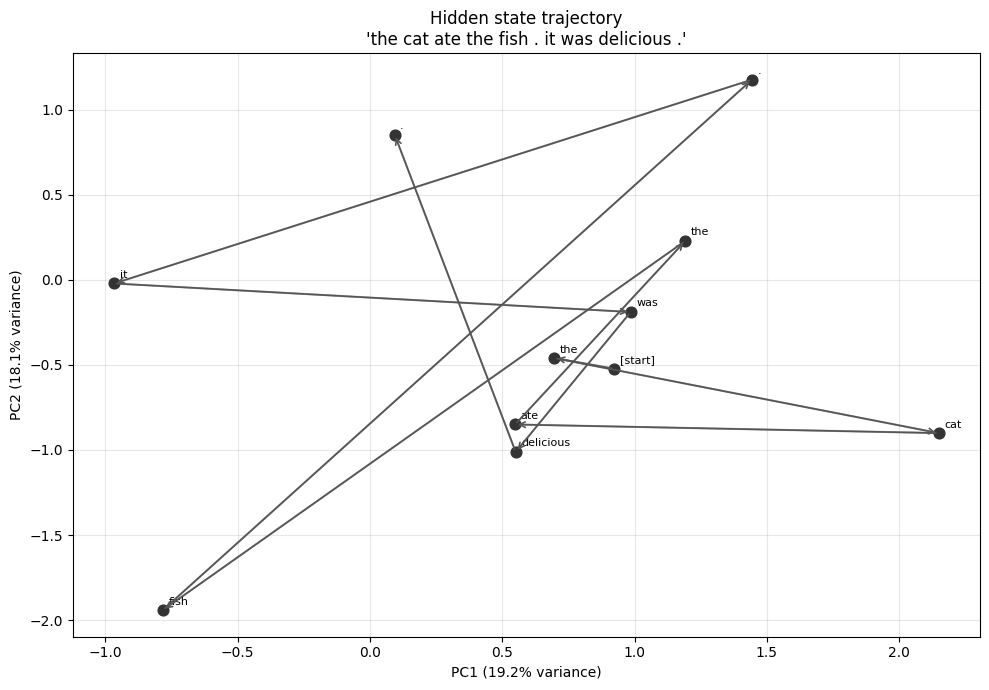

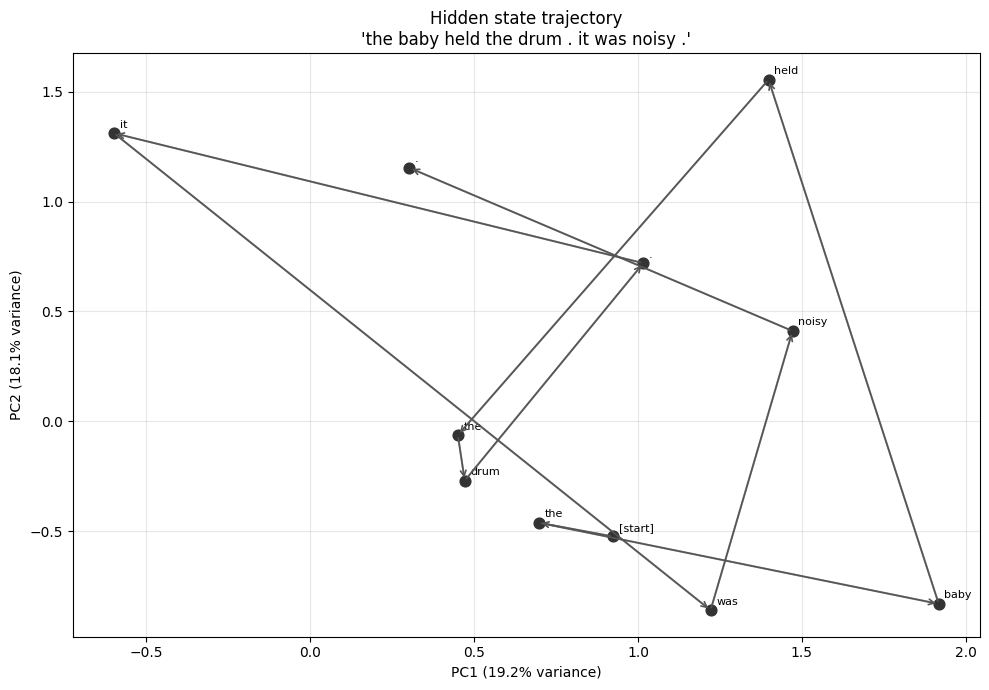

In [42]:
def plot_trajectory(sentence, pca):
    toks   = sentence.split()
    h      = np.zeros(H)
    states = [h.copy()]
    for w in toks:
        h, _, _ = forward_pass(one_hot(word2idx[w], V), h)
        states.append(h.copy())
    coords = pca.transform(np.array(states))

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.plot(coords[:, 0], coords[:, 1], color="#aaaaaa", linewidth=1.5, zorder=1)
    for i, label in enumerate(["[start]"] + toks):
        ax.scatter(coords[i, 0], coords[i, 1], color="#333333", s=60, zorder=3)
        ax.annotate(label, (coords[i, 0], coords[i, 1]), fontsize=8,
                    xytext=(4, 4), textcoords="offset points")
    for i in range(len(coords) - 1):
        ax.annotate("", xy=coords[i+1], xytext=coords[i],
                    arrowprops=dict(arrowstyle="->", color="#555555", lw=1.2))
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% variance)")
    ax.set_title(f"Hidden state trajectory\n'{sentence}'")
    ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_trajectory("the cat ate the fish . it was delicious .", pca)
plot_trajectory("the baby held the drum . it was noisy .",   pca)
